In [1]:
# CELL 1 — Imports and GPU setup

import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, Dense, Flatten, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing import image


2025-12-06 05:11:51.423019: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764997911.656396      71 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764997911.722616      71 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# CELL 2 — Dataset paths + hyperparameters (SCRATCH)

MODE = "scratch"   # SCRATCH ONLY

# Dataset root based on YOUR Kaggle structure
DATA_ROOT = "/kaggle/input/fruits/fruits-360_100x100/fruits-360"

TRAIN_DIR = DATA_ROOT + "/Training"
TEST_DIR  = DATA_ROOT + "/Test"

print("Dataset Root:", DATA_ROOT)
print("Training Path:", TRAIN_DIR)
print("Test Path:", TEST_DIR)

# Scratch CNN settings
IMAGE_SIZE = (100, 100)
BATCH_SIZE = 64
EPOCHS = 20

OUTPUT_MODEL_PATH = "/kaggle/working/cnn_from_scratch_fruits_best.h5"

print("\nMODE:", MODE)
print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)
print("Model will be saved to:", OUTPUT_MODEL_PATH)


Dataset Root: /kaggle/input/fruits/fruits-360_100x100/fruits-360
Training Path: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
Test Path: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Test

MODE: scratch
IMAGE_SIZE: (100, 100)
BATCH_SIZE: 64
EPOCHS: 20
Model will be saved to: /kaggle/working/cnn_from_scratch_fruits_best.h5


In [3]:
# CELL 3 — Data Generators

SEED = 33

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.12,
    height_shift_range=0.12,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = train_generator.num_classes
print("Number of Classes:", num_classes)


Found 96035 images belonging to 228 classes.
Found 23915 images belonging to 228 classes.
Found 39999 images belonging to 228 classes.
Number of Classes: 228


In [4]:
# CELL 4 — Build Scratch CNN

model = Sequential([
    Conv2D(16, (2,2), padding='same', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    Activation('relu'),
    MaxPooling2D((2,2)),

    Conv2D(32, (2,2), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (2,2), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (2,2), padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Dropout(0.3),
    Flatten(),

    Dense(150, activation='relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1764998079.742182      71 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 16)   │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100, 100, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 150)            │       691,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 228)            │        34,428 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769,218 (2.93 MB)

 Trainable params: 769,218 (2.93 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# CELL 5 — Compile + Safe Checkpoints

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# SAVE BEST MODEL
checkpoint_best = ModelCheckpoint(
    "/kaggle/working/best_model.h5",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True
)

# SAVE EVERY EPOCH (so even if kernel restarts, you still have models)
checkpoint_every = ModelCheckpoint(
    "/kaggle/working/epoch_{epoch:02d}.h5",
    verbose=1,
    save_best_only=False
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=6,
    restore_best_weights=True
)

callbacks = [checkpoint_best, checkpoint_every, early_stop]

print("Callbacks configured.")


Callbacks configured.


In [6]:
# CELL 6 — Train Model

steps_per_epoch = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(val_generator.samples / BATCH_SIZE)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1764998084.524259     125 service.cc:148] XLA service 0x799974088e60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764998084.525280     125 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764998084.937168     125 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764998088.184544     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_accuracy improved from -inf to 0.80381, saving model to /kaggle/working/best_model.h5



Epoch 1: saving model to /kaggle/working/epoch_01.h5


...

1501/1501 - 385s - 256ms/step - accuracy: 0.9395 - loss: 0.1727 - val_accuracy: 0.9598 - val_loss: 0.1545
Epoch 18/20

Epoch 18: val_accuracy did not improve from 0.96839

Epoch 18: saving model to /kaggle/working/epoch_18.h5


1501/1501 - 406s - 271ms/step - accuracy: 0.9409 - loss: 0.1673 - val_accuracy: 0.9593 - val_loss: 0.1388
Epoch 19/20

Epoch 19: val_accuracy improved from 0.96839 to 0.96960, saving model to /kaggle/working/best_model.h5



Epoch 19: saving model to /kaggle/working/epoch_19.h5


1501/1501 - 413s - 275ms/step - accuracy: 0.9442 - loss: 0.1606 - val_accuracy: 0.9696 - val_loss: 0.1171
Epoch 20/20

Epoch 20: val_accuracy did not improve from 0.96960

Epoch 20: saving model to /kaggle/working/epoch_20.h5


1501/1501 - 417s - 278ms/step - accuracy: 0.9475 - loss: 0.1492 - val_accuracy: 0.9642 - val_loss: 0.1326


In [7]:
# CELL 7 — Save FINAL model

model.save("/kaggle/working/final_model.h5")
model.save("/kaggle/working/final_model.keras")

print("Saved final_model.h5 and final_model.keras!")


Saved final_model.h5 and final_model.keras!


In [8]:
# CELL 8 — Evaluate

loss, acc = model.evaluate(test_generator, verbose=2)
print("Test Loss:", loss)
print("Test Accuracy:", acc)


625/625 - 420s - 672ms/step - accuracy: 0.9844 - loss: 0.0776
Test Loss: 0.07761139422655106
Test Accuracy: 0.9843745827674866


625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 74ms/step


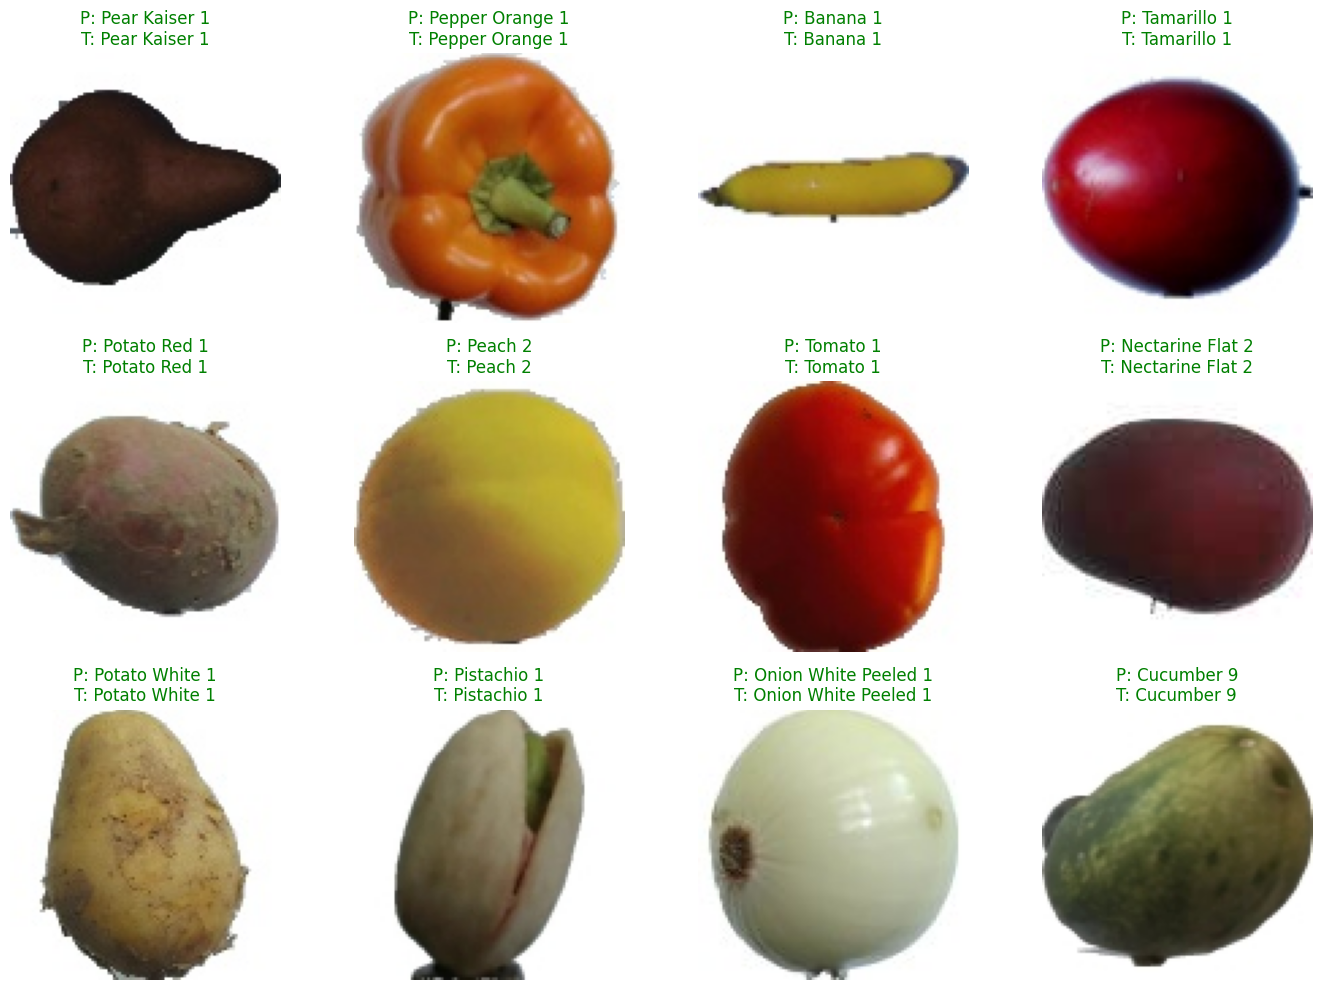

In [9]:
# CELL 9 — Predictions + visualization on random test images

import matplotlib.pyplot as plt
import numpy as np

preds = model.predict(test_generator, verbose=1)
pred_idx = np.argmax(preds, axis=1)
true_idx = test_generator.classes

labels_map = {v:k for k,v in test_generator.class_indices.items()}

# plot 12 random predictions
indices = random.sample(range(len(test_generator.filenames)), 12)

plt.figure(figsize=(14,10))
for i, idx in enumerate(indices):
    file_path = test_generator.filepaths[idx]
    img = plt.imread(file_path)
    p = pred_idx[idx]
    t = true_idx[idx]

    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.title(f"P: {labels_map[p]}\nT: {labels_map[t]}", 
              color="green" if p == t else "red")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Search common locations for model files - may take a few seconds
!echo "Listing /kaggle/working (should show files):"
!ls -lah /kaggle/working || true

!echo "\nSearch for .h5 files under /kaggle (fast):"
!find /kaggle -type f -name "*.h5" -print -exec ls -lh {} \; 2>/dev/null || true

!echo "\nSearch for .h5 files across root (limited depth to avoid huge scan):"
!find / -maxdepth 4 -type f -name "*.h5" -print -exec ls -lh {} \; 2>/dev/null | head -n 100 || true

!echo "\nSearch for .keras files:"
!find / -maxdepth 4 -type f -name "*.keras" -print -exec ls -lh {} \; 2>/dev/null | head -n 100 || true


Listing /kaggle/working (should show files):
total 204M
drwxr-xr-x 3 root root 4.0K Dec  6 07:34 .
drwxr-xr-x 5 root root 4.0K Dec  6 05:11 ..
-rw-r--r-- 1 root root 8.9M Dec  6 07:27 best_model.h5
-rw-r--r-- 1 root root 8.9M Dec  6 05:31 epoch_01.h5
-rw-r--r-- 1 root root 8.9M Dec  6 05:37 epoch_02.h5
-rw-r--r-- 1 root root 8.9M Dec  6 05:44 epoch_03.h5
-rw-r--r-- 1 root root 8.9M Dec  6 05:50 epoch_04.h5
-rw-r--r-- 1 root root 8.9M Dec  6 05:56 epoch_05.h5
-rw-r--r-- 1 root root 8.9M Dec  6 06:03 epoch_06.h5
-rw-r--r-- 1 root root 8.9M Dec  6 06:09 epoch_07.h5
-rw-r--r-- 1 root root 8.9M Dec  6 06:16 epoch_08.h5
-rw-r--r-- 1 root root 8.9M Dec  6 06:22 epoch_09.h5
-rw-r--r-- 1 root root 8.9M Dec  6 06:28 epoch_10.h5
-rw-r--r-- 1 root root 8.9M Dec  6 06:35 epoch_11.h5
-rw-r--r-- 1 root root 8.9M Dec  6 06:41 epoch_12.h5
-rw-r--r-- 1 root root 8.9M Dec  6 06:47 epoch_13.h5
-rw-r--r-- 1 root root 8.9M Dec  6 06:54 epoch_14.h5
-rw-r--r-- 1 root root 8.9M Dec  6 07:00 epoch_15.h5
-rw-r--